<a href="https://colab.research.google.com/github/Rajukc45/Capstone-project/blob/main/ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q google-genai imbalanced-learn scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [4]:
DATA_PATH = "creditcard.csv"   # change if uploaded filename differs
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (16383, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Basic data inspection

In [5]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum().sort_values(ascending=False).head(20))
print("\nClass distribution:\n", df["Class"].value_counts())
print("\nFraud ratio:", df["Class"].mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16383 entries, 0 to 16382
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    16383 non-null  int64  
 1   V1      16383 non-null  float64
 2   V2      16383 non-null  float64
 3   V3      16383 non-null  float64
 4   V4      16383 non-null  float64
 5   V5      16383 non-null  float64
 6   V6      16383 non-null  float64
 7   V7      16383 non-null  float64
 8   V8      16383 non-null  float64
 9   V9      16383 non-null  float64
 10  V10     16383 non-null  float64
 11  V11     16383 non-null  float64
 12  V12     16383 non-null  float64
 13  V13     16383 non-null  float64
 14  V14     16383 non-null  float64
 15  V15     16383 non-null  float64
 16  V16     16383 non-null  float64
 17  V17     16383 non-null  float64
 18  V18     16383 non-null  float64
 19  V19     16383 non-null  float64
 20  V20     16383 non-null  float64
 21  V21     16383 non-null  float64
 22

Feature / target split

In [6]:
TARGET_COL = "Class"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (16383, 30)
y shape: (16383,)


Train-test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (13106, 30) (13106,)
Test shape: (3277, 30) (3277,)


Preprocessing

In [8]:
imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imp),
    columns=X_train_imp.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp),
    columns=X_test_imp.columns
)

print("Preprocessing complete.")

Preprocessing complete.


Handle class imbalance with SMOTE

In [9]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_balanced).value_counts().to_dict())

Before SMOTE: {0: 13048, 1: 58}
After SMOTE: {0: 13048, 1: 13048}


Train multiple models

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )
}

Evaluation helper

In [12]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    print(f"\n===== {model_name} =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("ROC-AUC  :", auc)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f"{model_name} AUC = {auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {model_name}")
        plt.legend()
        plt.show()

    return {
        "model_name": model_name,
        "model": model,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": auc
    }

Train and compare models


===== Logistic Regression =====
Accuracy : 0.9951174855050351
Precision: 0.4782608695652174
Recall   : 0.7333333333333333
F1-score : 0.5789473684210527
ROC-AUC  : 0.9318822808093196

Classification Report:
              precision    recall  f1-score   support

           0     0.9988    0.9963    0.9975      3262
           1     0.4783    0.7333    0.5789        15

    accuracy                         0.9951      3277
   macro avg     0.7385    0.8648    0.7882      3277
weighted avg     0.9964    0.9951    0.9956      3277



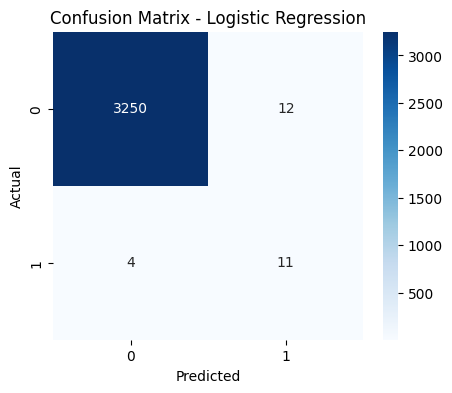

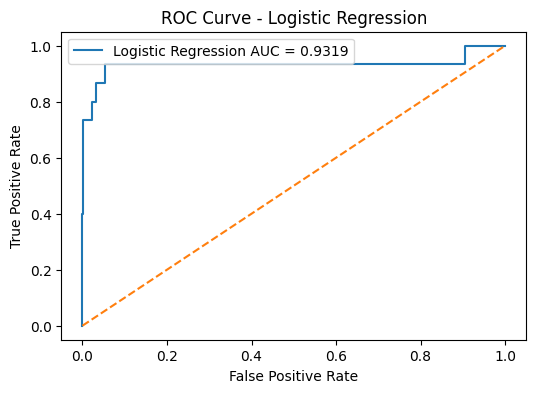


===== Random Forest =====
Accuracy : 0.9978638999084528
Precision: 0.7857142857142857
Recall   : 0.7333333333333333
F1-score : 0.7586206896551724
ROC-AUC  : 0.9931126098508073

Classification Report:
              precision    recall  f1-score   support

           0     0.9988    0.9991    0.9989      3262
           1     0.7857    0.7333    0.7586        15

    accuracy                         0.9979      3277
   macro avg     0.8922    0.8662    0.8788      3277
weighted avg     0.9978    0.9979    0.9978      3277



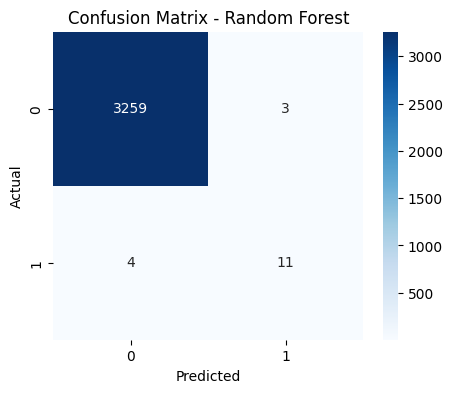

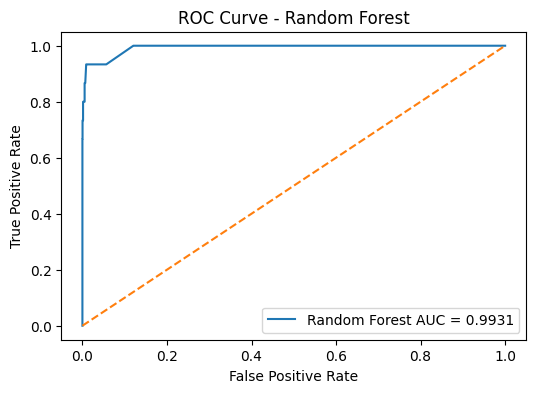

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Random Forest,0.997864,0.785714,0.733333,0.758621,0.993113
0,Logistic Regression,0.995117,0.478261,0.733333,0.578947,0.931882


In [13]:
results = []

for model_name, model in models.items():
    result = evaluate_model(
        model,
        X_train_balanced, y_train_balanced,
        X_test_scaled, y_test,
        model_name
    )
    results.append(result)

results_df = pd.DataFrame([
    {
        "Model": r["model_name"],
        "Accuracy": r["accuracy"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1-score": r["f1_score"],
        "ROC-AUC": r["roc_auc"]
    }
    for r in results
]).sort_values(by="ROC-AUC", ascending=False)

results_df

Select the best-performing model

In [14]:
best_result = max(results, key=lambda x: x["roc_auc"] if x["roc_auc"] is not None else -1)
best_model = best_result["model"]

print("Best model selected:", best_result["model_name"])
print(best_result)

Best model selected: Random Forest
{'model_name': 'Random Forest', 'model': RandomForestClassifier(max_depth=12, n_estimators=200, n_jobs=-1,
                       random_state=42), 'accuracy': 0.9978638999084528, 'precision': 0.7857142857142857, 'recall': 0.7333333333333333, 'f1_score': 0.7586206896551724, 'roc_auc': np.float64(0.9931126098508073)}


Save artifacts for deployment / versioning

In [15]:
MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(best_model, f"{MODEL_DIR}/best_fraud_model.pkl")
joblib.dump(imputer, f"{MODEL_DIR}/imputer.pkl")
joblib.dump(scaler, f"{MODEL_DIR}/scaler.pkl")

metadata = {
    "best_model_name": best_result["model_name"],
    "metrics": {
        "accuracy": best_result["accuracy"],
        "precision": best_result["precision"],
        "recall": best_result["recall"],
        "f1_score": best_result["f1_score"],
        "roc_auc": best_result["roc_auc"]
    },
    "features": list(X.columns),
    "version": "v1.0"
}

with open(f"{MODEL_DIR}/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Model artifacts saved.")

Model artifacts saved.


Reload saved model

In [16]:
loaded_model = joblib.load(f"{MODEL_DIR}/best_fraud_model.pkl")
loaded_imputer = joblib.load(f"{MODEL_DIR}/imputer.pkl")
loaded_scaler = joblib.load(f"{MODEL_DIR}/scaler.pkl")

print("Artifacts loaded successfully.")

Artifacts loaded successfully.


Fraud prediction function

In [17]:
def predict_transaction(transaction_df, model, imputer, scaler):
    """
    transaction_df: pandas DataFrame with same feature columns as training data
    """
    tx_imp = pd.DataFrame(
        imputer.transform(transaction_df),
        columns=transaction_df.columns
    )

    tx_scaled = pd.DataFrame(
        scaler.transform(tx_imp),
        columns=tx_imp.columns
    )

    pred = model.predict(tx_scaled)[0]

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(tx_scaled)[0][1]
    else:
        prob = None

    label = "Fraudulent" if pred == 1 else "Legitimate"

    return {
        "prediction": int(pred),
        "label": label,
        "fraud_probability": float(prob) if prob is not None else None
    }

Test prediction on one sample

In [18]:
sample_tx = X_test.iloc[[0]].copy()
sample_result = predict_transaction(sample_tx, loaded_model, loaded_imputer, loaded_scaler)

print("Prediction result:")
print(sample_result)

Prediction result:
{'prediction': 0, 'label': 'Legitimate', 'fraud_probability': 0.005}


Gemini API setup for explanations

In [24]:
import os
from getpass import getpass

os.environ["GEMINI_API_KEY"] = getpass("Enter your Gemini API key: ")

Enter your Gemini API key: ··········


In [27]:
from google import genai

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

In [28]:
client = genai.Client()

In [29]:
model="gemini-2.5-flash"

In [32]:
def generate_fraud_explanation(transaction_row, prediction_result):
    prompt = f"""
Transaction classified as: {prediction_result['label']}
Fraud probability: {prediction_result['fraud_probability']}

Explain why this transaction may be fraud or legitimate in simple terms.
"""

    response = client.models.generate_content(
        model="gemini-1.5-flash",
        contents=prompt
    )

    return response.text

Gemini explanation generator

In [33]:
from google import genai

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

In [34]:
def generate_fraud_explanation(transaction_row, prediction_result, top_n_features=8):
    """
    transaction_row: single-row DataFrame
    prediction_result: dict returned by predict_transaction()
    """
    tx_dict = transaction_row.iloc[0].to_dict()

    # Pick a subset of features for a shorter explanation prompt
    selected_items = list(tx_dict.items())[:top_n_features]
    selected_features_text = "\n".join([f"- {k}: {v}" for k, v in selected_items])

    prompt = f"""
You are an AI fraud analyst assistant.

A credit card transaction has been classified by a machine learning fraud detection model.

Classification result:
- Label: {prediction_result['label']}
- Fraud probability: {prediction_result['fraud_probability']}

Transaction features:
{selected_features_text}

Write a short, human-understandable explanation for the decision.
Requirements:
1. Mention likely reasons the transaction was flagged or considered legitimate.
2. Use simple language.
3. Avoid claiming certainty.
4. Mention unusual amount, timing, or behavior only if supported by the features shown.
5. End with a brief risk summary.

Return only the explanation text.
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    return response.text

Generate explanation for one transaction

In [35]:
explanation = generate_fraud_explanation(sample_tx, sample_result)
print("Explanation:\n")
print(explanation)

ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

Batch fraud detection + explanation

In [36]:
def batch_predict_and_explain(input_df, model, imputer, scaler, explain_with_gemini=False):
    outputs = []

    for i in range(len(input_df)):
        row_df = input_df.iloc[[i]].copy()
        pred_result = predict_transaction(row_df, model, imputer, scaler)

        explanation = None
        if explain_with_gemini:
            try:
                explanation = generate_fraud_explanation(row_df, pred_result)
            except Exception as e:
                explanation = f"Explanation generation failed: {str(e)}"

        record = {
            "index": input_df.index[i],
            "prediction": pred_result["prediction"],
            "label": pred_result["label"],
            "fraud_probability": pred_result["fraud_probability"],
            "explanation": explanation
        }
        outputs.append(record)

    return pd.DataFrame(outputs)

In [37]:
batch_samples = X_test.iloc[:5].copy()
batch_results = batch_predict_and_explain(
    batch_samples,
    loaded_model,
    loaded_imputer,
    loaded_scaler,
    explain_with_gemini=True
)

batch_results

,index,prediction,label,fraud_probability,explanation
0,2430,0,Legitimate,0.005,Explanation generation failed: 503 UNAVAILABLE...
1,145,0,Legitimate,0.030,Explanation generation failed: 503 UNAVAILABLE...
2,2445,0,Legitimate,0.000,Explanation generation failed: 503 UNAVAILABLE...
3,12119,0,Legitimate,0.000,Explanation generation failed: 503 UNAVAILABLE...
4,3011,0,Legitimate,0.000,Explanation generation failed: 503 UNAVAILABLE...


Export results for reporting


In [38]:
batch_results.to_csv("fraud_detection_results_with_explanations.csv", index=False)
print("Exported results to fraud_detection_results_with_explanations.csv")

Exported results to fraud_detection_results_with_explanations.csv


simple manual transaction entry

In [39]:
feature_columns = list(X.columns)
print("Required columns:")
print(feature_columns)

Required columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [40]:
manual_tx = pd.DataFrame([{
    col: 0 for col in feature_columns
}])

manual_result = predict_transaction(manual_tx, loaded_model, loaded_imputer, loaded_scaler)
manual_explanation = generate_fraud_explanation(manual_tx, manual_result)

print(manual_result)
print(manual_explanation)

ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}